In [247]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [248]:
img = Image.open(r"C:\Users\USER\Downloads\dynamo.png")
img.show()

In [249]:
img.size


(1536, 1024)

Initialize the sizes for smooth matrix recreation in future

In [250]:
m = 1536
n = 1024

Get the pixels of the image into a 1D array

In [251]:
imgmat = np.array(list(img.getdata()), float)
print(imgmat.shape)
print(imgmat.dtype)

(1572864, 3)
float64


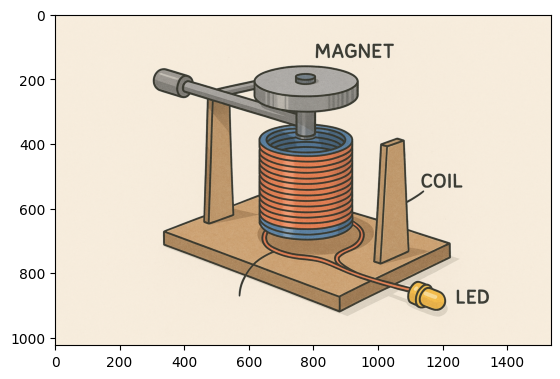

In [252]:
imgmatmat = imgmat.reshape(n, m, 3)
plt.imshow(imgmatmat.astype("uint8"))

The image comtains 3 color bands (red, green, blue), based on the shape, each column is a column vector 

of each specific color band, so we have 3 columns and each column has 1048576 pixels

In [253]:
# Get the first red band column

redband = imgmat[:, :1]
print(redband.shape)
print(redband[:3, :])

(1572864, 1)
[[247.]
 [247.]
 [248.]]


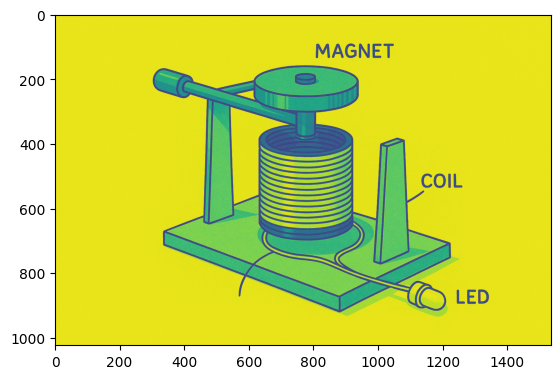

In [254]:
redbandmat = redband.reshape(n, m)
plt.imshow(redbandmat)

In [255]:
greenband = imgmat[:, 1:2]
print(greenband.shape)
print(greenband[:3, :])

(1572864, 1)
[[238.]
 [237.]
 [239.]]


In [256]:
greenbandmat = greenband.reshape(n, m)
greenband.shape

(1572864, 1)

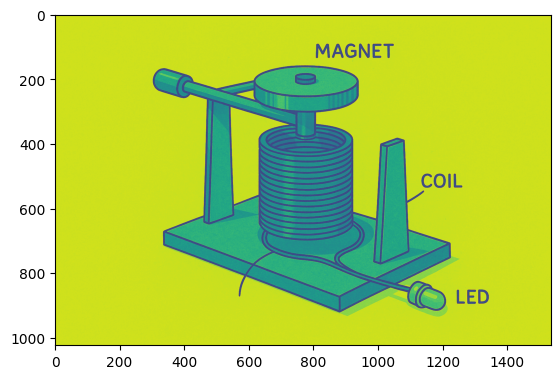

In [257]:
plt.imshow(greenbandmat)

In [258]:
blueband = imgmat[:, 2:3]
print(blueband.shape)
print(blueband[:3, :])

(1572864, 1)
[[223.]
 [223.]
 [223.]]


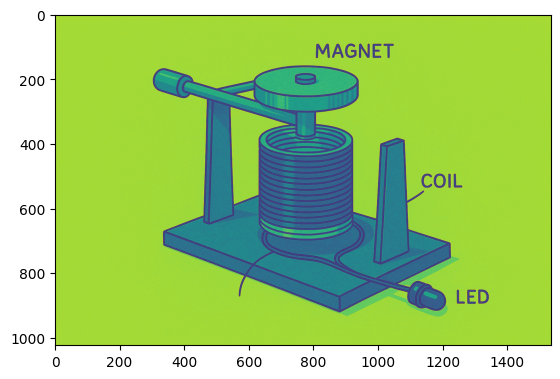

In [259]:
bluebandmat = blueband.reshape(n, m)
plt.imshow(bluebandmat)

In [260]:
print(f"Redband: {redbandmat.shape}")
print(f"Greenband: {greenbandmat.shape}")
print(f'Blueband: {bluebandmat.shape}')

Redband: (1024, 1536)
Greenband: (1024, 1536)
Blueband: (1024, 1536)


Here, I'll do the SVD of each band matrix, then after SVD i'll restack them back to form the compressed image

In [261]:
# Redband matrix SVD
U, S, VT = np.linalg.svd(redbandmat)

In [262]:
redbandmat1 = U[:,:10] @ np.diag(S[:10]) @ VT[:10, :]
redbandmat1.shape

(1024, 1536)

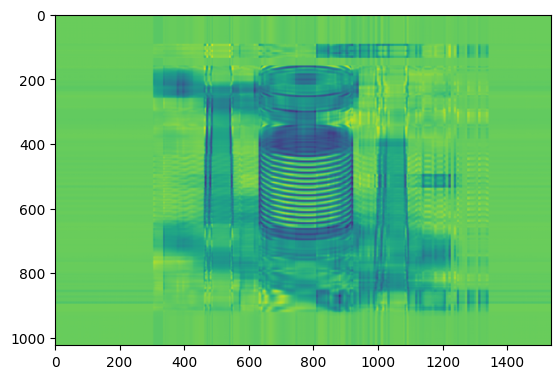

In [263]:
plt.imshow(redbandmat1)

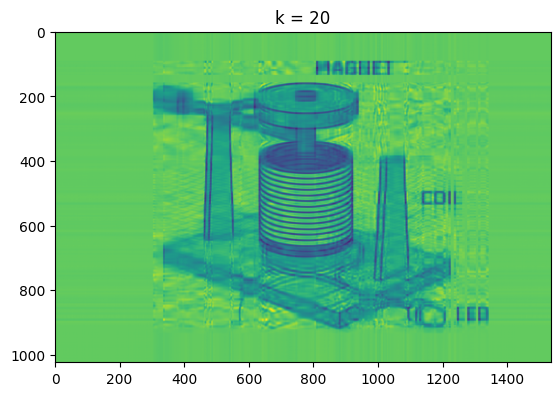

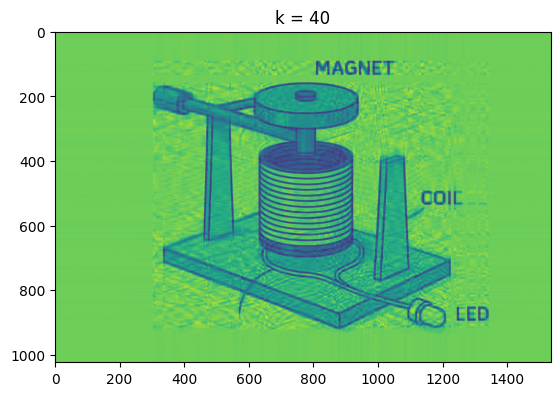

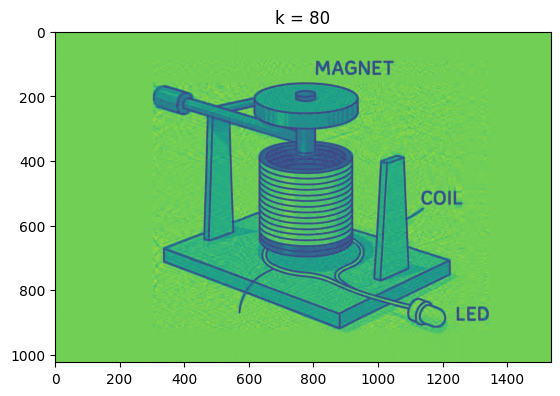

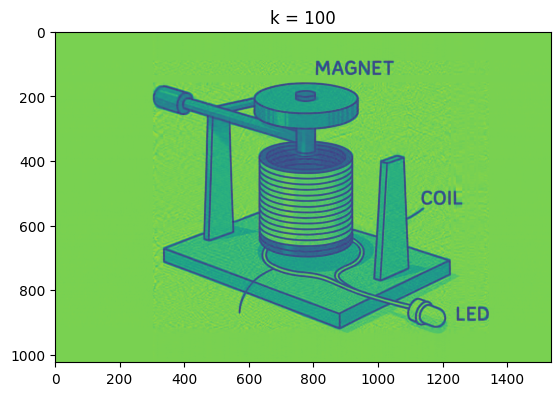

In [264]:

for k in [20, 40, 80, 100]:
    redbandmat1 = U[:,:k] @ np.diag(S[:k]) @ VT[:k, :]
    plt.imshow(redbandmat1)
    plt.title("k = %s" % k)
    plt.show()

Considering the SVD above, using k=100 is a good value to give us a clear image, we then do the SVD of the remaining color bands

In [265]:
k = 100

In [266]:
# Green band SVD
U, S, VT = np.linalg.svd(greenbandmat)

In [267]:
greenbandmat1 = U[:,:k] @ np.diag(S[:k]) @ VT[:k, :]

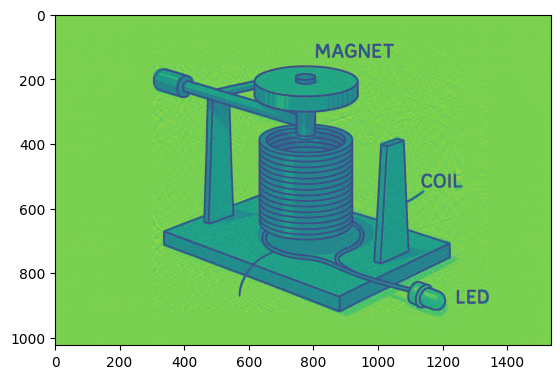

In [268]:
plt.imshow(greenbandmat1)

In [269]:
# Red band SVD

U, S, VT = np.linalg.svd(bluebandmat)

In [270]:
bluebandmat1 = U[:,:k] @ np.diag(S[:k]) @ VT[:k, :]

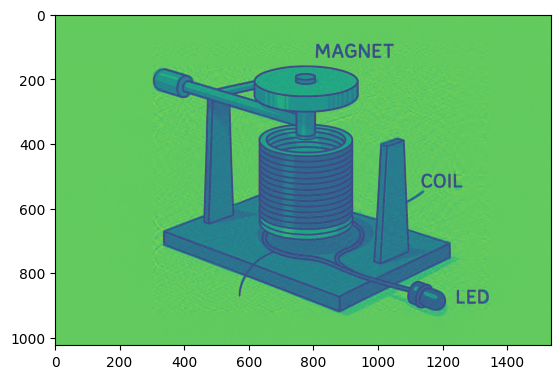

In [271]:
plt.imshow(bluebandmat1)

An colored image is of the shape (Height, width, 3), so we need to stack our color band matrices in 3 Dimension to recreate our image

In [272]:
reconstimg = np.stack([redbandmat1, greenbandmat1, bluebandmat1], axis=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-28.422044364100074..313.8233951073452].


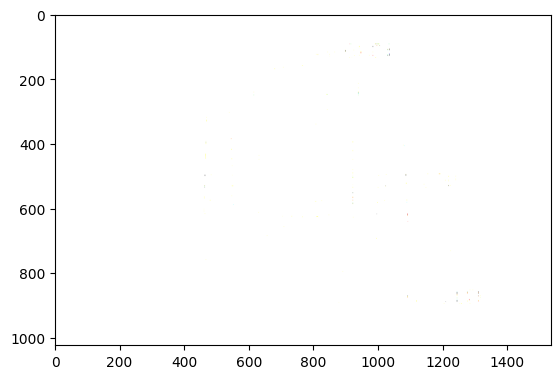

In [273]:
plt.imshow(reconstimg)

Our image pixels should range from 0 to 255, because our range starts from below zero and ends above 255, we have to clip it, the type of value for images should also be uint8 and not floats or integers

In [274]:
print(reconstimg.min(), reconstimg.max(), reconstimg.dtype)

-28.422044364100074 313.8233951073452 float64


In [275]:
reconstimg = np.clip(reconstimg, 0, 255)

In [276]:
reconstimg = reconstimg.astype(np.uint8)

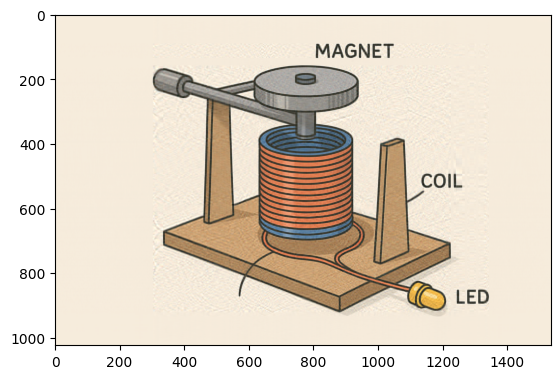

In [277]:
plt.imshow(reconstimg)

Let us then compare the size of the image before and after compression and see the percentage compression

In [278]:
#  Before compression
m2, n2 = img.size
size1 = m2 * n2
size1

1572864

In [279]:
size2 = k*m2 + k + k*n2
size2

256100

In [280]:
percentage_comp = ((size1 - size2) / size1) * 100
percentage_comp

83.71760050455728

The image underwent 83% compression via simple SVD 😁😁